In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer

import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

# This will ensure the outputs of the .transform() method are pandas data frames
from sklearn import set_config
set_config(transform_output='pandas')

In [94]:
playlist_df = pd.read_csv("D:/WBS/Moosic/3_spotify_5000_songs.csv")

In [95]:
playlist_df.head()

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [96]:
playlist_df.columns

Index(['Unnamed: 0',
       'name                                                                                                                                                                             ',
       'artist                                          ', 'danceability ',
       'energy   ', 'key ', 'loudness ', 'mode ', 'speechiness ',
       'acousticness ', 'instrumentalness ', 'liveness ', 'valence ',
       'tempo   ', 'type ', 'duration_ms ', 'time_signature ',
       'id                     ', 'html'],
      dtype='object')

In [97]:
playlist_df.columns = playlist_df.columns.str.strip()

In [98]:
playlist_df["artist_and_song"] = playlist_df["artist"] + " - " + playlist_df["name"]


In [99]:
playlist_df = playlist_df.set_index("artist_and_song")

In [100]:
playlist_df = playlist_df.drop(["artist", "name", "Unnamed: 0"], axis=1)

In [101]:
playlist_df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
artist_and_song,,,,,,,,,,,,,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
Antônio Carlos Jobim - Saudade De Bahia,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
"Martinho Da Vila - Canta Canta, Minha Gente",0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
Chico César - Mulher Eu Sei,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
Kurt Elling - Rosa Morena,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [102]:
playlist_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5235 entries, Gilberto Gil                                     - Se Eu Quiser Falar Com Deus                                                                                                                                                       to Maurice Ravel                                    - Ravel: Boléro, M. 81                                                                                                                                                           
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      5235 non-null   float64
 1   energy            5235 non-null   float64
 2   key               5235 non-null   int64  
 3   loudness          5235 non-null   float64
 4   mode              5235 non-null   int64  
 5   speechiness       5235 non-null   float64
 6   acousticness      5235 non-null   float64
 7   instrumentalness  523

In [103]:
playlist_df = playlist_df.astype({col: 'float' for col in playlist_df.select_dtypes(include='int').columns})

In [104]:
# Exclude columns with features that are less helpful
playlist_df = playlist_df.drop(["type", "id", "html", "key", "mode", "energy", "liveness", "loudness", "duration_ms", "time_signature"], axis=1)

In [105]:
# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scale the playlist DataFrame
playlist_minmax = scaler.fit_transform(playlist_df)

In [106]:
playlist_minmax.head()

,danceability,speechiness,acousticness,instrumentalness,valence,tempo
artist_and_song,,,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,0.680455,0.076797,0.696787,0.000060,0.310660,0.515800
Antônio Carlos Jobim - Saudade De Bahia,0.767322,0.037691,0.217871,0.000002,0.703553,0.584322
"Martinho Da Vila - Canta Canta, Minha Gente",0.880041,0.377996,0.454819,0.000064,0.918782,0.437862
Chico César - Mulher Eu Sei,0.729059,0.051307,0.882530,0.000041,0.531980,0.499098
Kurt Elling - Rosa Morena,0.673216,0.041394,0.919679,0.000348,0.408122,0.565171


In [107]:
# Initialise the PCA object
pca = PCA()

# Fit the PCA object to the data
pca.fit(playlist_minmax)

# Transform scaled_features_df based on the fit calculations
pca_basic_playlist_df = pca.transform(playlist_minmax)

pca_basic_playlist_df

,pca0,pca1,pca2,pca3,pca4,pca5
artist_and_song,,,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,-0.042041,0.441576,-0.235409,0.131537,0.089717,-0.000606
Antônio Carlos Jobim - Saudade De Bahia,-0.419687,0.086939,0.099801,0.026656,0.039507,-0.057394
"Martinho Da Vila - Canta Canta, Minha Gente",-0.476917,0.360630,0.267699,0.101959,-0.061721,0.303359
Chico César - Mulher Eu Sei,-0.094146,0.669645,-0.072524,0.076166,0.040807,-0.007913
Kurt Elling - Rosa Morena,-0.006962,0.665718,-0.178725,0.044341,0.106022,-0.019852
...,...,...,...,...,...,...
"Pyotr Ilyich Tchaikovsky - 1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.855979,0.356162,-0.122077,0.021664,-0.089044,-0.000355
"Tristan Murail - Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.638718,0.360490,-0.328203,0.009809,-0.130046,-0.008965
"Arnold Schoenberg - Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",1.128294,0.300508,-0.034545,0.001073,-0.193110,0.004023


In [108]:
# Get the variance explained by each principal component
explained_variance_array = pca.explained_variance_ratio_

explained_variance_array

array([0.49843854, 0.27791927, 0.12650553, 0.04791519, 0.03618035,
       0.01304111])

In [109]:
pd.DataFrame(explained_variance_array, columns=["Variance explained"])

,Variance explained
0,0.498439
1,0.277919
2,0.126506
3,0.047915
4,0.036180
5,0.013041


In [110]:
cumulative_sum_of_variance = np.cumsum(explained_variance_array)

cumulative_sum_of_variance

array([0.49843854, 0.77635781, 0.90286335, 0.95077854, 0.98695889,
       1.        ])

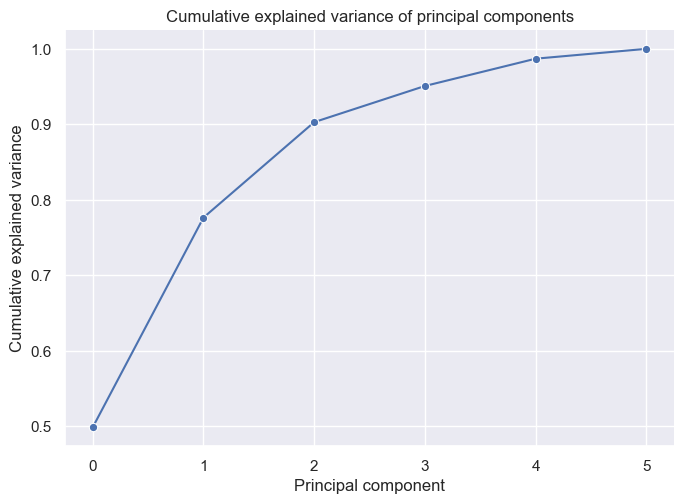

In [111]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_variance_array)),  # Set the x-axis to be the principal component index
      y = cumulative_sum_of_variance,  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

In [112]:
# Create a PCA object
pca_variance = PCA(n_components = 0.95)

In [113]:
# Fit the PCA object to the scaled features dataframe and transform it
pca_variance_playlist_df = pca_variance.fit_transform(pca_basic_playlist_df)

# The dataframe now contains the principal components of the scaled features dataframe
pca_variance_playlist_df

,pca0,pca1,pca2,pca3
artist_and_song,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,-0.042041,0.441576,-0.235409,0.131537
Antônio Carlos Jobim - Saudade De Bahia,-0.419687,0.086939,0.099801,0.026656
"Martinho Da Vila - Canta Canta, Minha Gente",-0.476917,0.360630,0.267699,0.101959
Chico César - Mulher Eu Sei,-0.094146,0.669645,-0.072524,0.076166
Kurt Elling - Rosa Morena,-0.006962,0.665718,-0.178725,0.044341
...,...,...,...,...
"Pyotr Ilyich Tchaikovsky - 1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.855979,0.356162,-0.122077,0.021664
"Tristan Murail - Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.638718,0.360490,-0.328203,0.009809
"Arnold Schoenberg - Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",1.128294,0.300508,-0.034545,0.001073


In [114]:
# Set the maximum number of clusters to try
max_k = 50

# Create an empty list to store the inertia scores
inertia_list = []

# Iterate over the range of cluster numbers
for k in range(1, max_k+1):

    # Create a KMeans object with the specified number of clusters
    myKMeans = KMeans(n_clusters = k,
                      random_state = 42)

    # Fit the KMeans model to the scaled data
    myKMeans.fit(pca_variance_playlist_df)

    # Append the inertia score to the list
    inertia_list.append(myKMeans.inertia_)

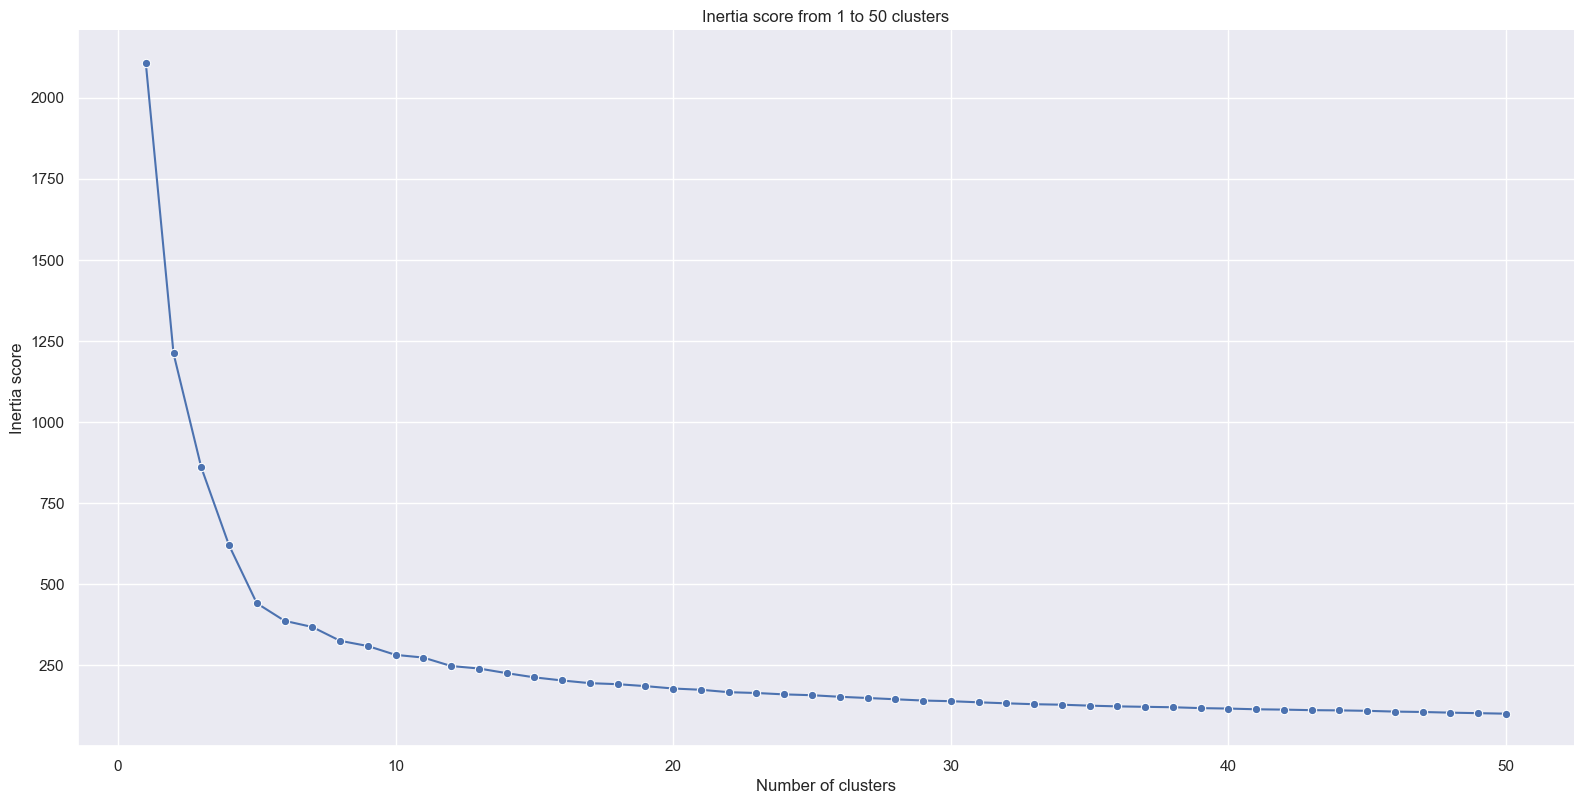

In [115]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(1, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 1 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

In [116]:
# Set the maximum number of clusters to try
max_k = 50

# Create an empty list to store the silhouette scores
sil_scores = []

for k in range(2, max_k):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(playlist_minmax)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(pca_variance_playlist_df, labels)

    # Append the silhouette score to the list
    sil_scores.append(sil_score)

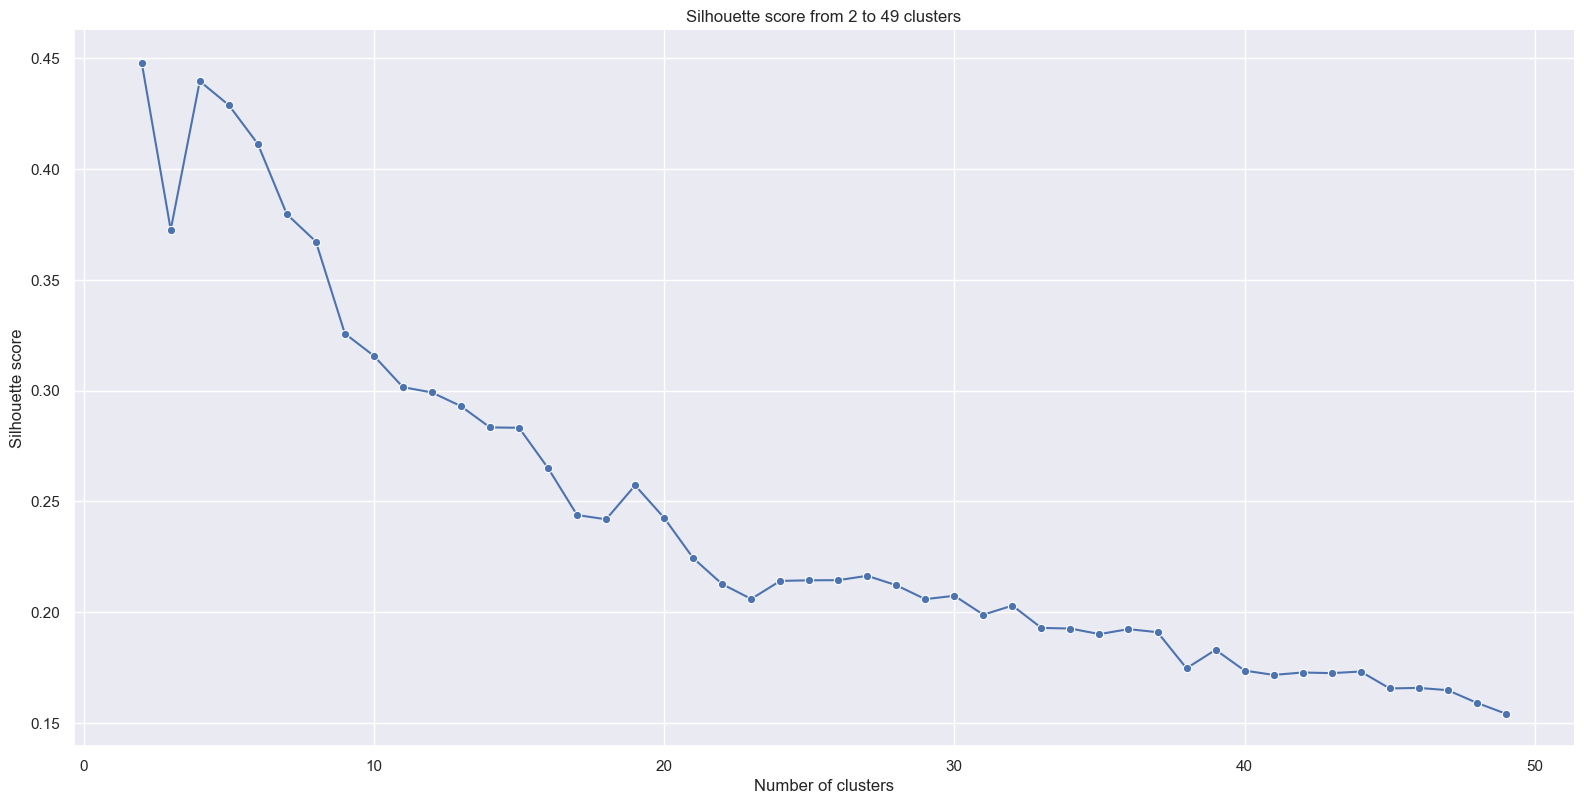

In [117]:
(
sns.relplot(y = sil_scores,
            x = range(2, max_k),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 2 to {max_k - 1} clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [118]:
# Initialise the model
my_kmeans = KMeans(n_clusters = 20, # you always choose the number of k here
                   random_state = 42)

# Fit the model to the data
my_kmeans.fit(pca_variance_playlist_df)

# Obtain the cluster output
clusters = my_kmeans.labels_

# Attach the cluster output to our original DataFrame
pca_variance_playlist_df["cluster"] = clusters

In [119]:
pca_variance_playlist_df.groupby(by="cluster").mean()

,pca0,pca1,pca2,pca3
cluster,,,,
0,0.897652,0.313782,-0.026653,-0.090198
1,-0.204773,-0.166257,-0.245047,0.142941
2,0.454539,-0.454753,0.251481,-0.021410
3,0.257709,0.557472,-0.422149,-0.056545
4,-0.429564,0.248699,0.198449,0.000369
5,-0.536485,-0.004589,0.225495,0.033396
6,0.988532,0.366432,0.020463,0.080271
7,-0.232151,-0.195870,-0.157948,-0.099803
8,-0.270993,0.164182,-0.030502,0.052567


In [120]:
pca_variance_playlist_df

,pca0,pca1,pca2,pca3,cluster
artist_and_song,,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,-0.042041,0.441576,-0.235409,0.131537,15
Antônio Carlos Jobim - Saudade De Bahia,-0.419687,0.086939,0.099801,0.026656,4
"Martinho Da Vila - Canta Canta, Minha Gente",-0.476917,0.360630,0.267699,0.101959,4
Chico César - Mulher Eu Sei,-0.094146,0.669645,-0.072524,0.076166,15
Kurt Elling - Rosa Morena,-0.006962,0.665718,-0.178725,0.044341,15
...,...,...,...,...,...
"Pyotr Ilyich Tchaikovsky - 1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.855979,0.356162,-0.122077,0.021664,0
"Tristan Murail - Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.638718,0.360490,-0.328203,0.009809,0
"Arnold Schoenberg - Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",1.128294,0.300508,-0.034545,0.001073,6


In [121]:
# Create an empty list to store the Scatterpolar object of each cluster
scatter_objects = []

# State the label for each arm of the chart
categories = pca_variance_playlist_df.columns

# Get the means of each feature for each cluster
cluster_feat_means = pca_variance_playlist_df.groupby(by="cluster").mean()

# Iterate over the unique clusters and add an object for each cluster to the list
for cluster in sorted(pca_variance_playlist_df['cluster'].unique()):

  # Find the mean value for each column of the cluster
  cluster_means = cluster_feat_means.loc[cluster]

  # Create a Scatterpolar object for the cluster
  cluster_scatter = go.Scatterpolar(
    r = cluster_means, # set the radial coordinates
    theta = categories, # the names of the columns
    fill = 'toself', # fills in the space with colour
    name = f'Cluster {cluster}' # adds the name of the cluster
  )

  # Add the Scatterpolar object to the list
  scatter_objects.append(cluster_scatter)

# Create the figure (the white area)
fig = go.Figure()

# Add the scatter objects to the figure
fig.add_traces(scatter_objects)

# Add extras to the plot, such as title
fig.update_layout(
  title_text = 'Radar chart of loudness and acousticness',
  height = 600,
  width = 800,
  polar = dict(
    radialaxis = dict(
      visible = True, # visibility of the numbers on the arm
      range = [0, 1] # scale of the plot
    )),
  showlegend = True
)

# Show the initialised plot and the trace objects
fig.show()

In [122]:
# Merge the original table with pca_variance_playlist_df based on the column pca_variance_playlist_df
merged_playlist_df = playlist_minmax.merge(
    pca_variance_playlist_df,
    on="artist_and_song",
    how="inner"
)

# Then we have the different features again and plot this merged df (table) to show the features in the clusters

In [123]:
merged_playlist_df

,danceability,speechiness,acousticness,instrumentalness,valence,tempo,pca0,pca1,pca2,pca3,cluster
artist_and_song,,,,,,,,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,0.680455,0.076797,0.696787,0.000060,0.310660,0.515800,-0.042041,0.441576,-0.235409,0.131537,15
Antônio Carlos Jobim - Saudade De Bahia,0.767322,0.037691,0.217871,0.000002,0.703553,0.584322,-0.419687,0.086939,0.099801,0.026656,4
"Martinho Da Vila - Canta Canta, Minha Gente",0.880041,0.377996,0.454819,0.000064,0.918782,0.437862,-0.476917,0.360630,0.267699,0.101959,4
"Martinho Da Vila - Canta Canta, Minha Gente",0.880041,0.377996,0.454819,0.000064,0.918782,0.437862,-0.442400,0.206373,0.181311,0.054335,4
Chico César - Mulher Eu Sei,0.729059,0.051307,0.882530,0.000041,0.531980,0.499098,-0.094146,0.669645,-0.072524,0.076166,15
...,...,...,...,...,...,...,...,...,...,...,...
"Pyotr Ilyich Tchaikovsky - 1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.208893,0.051525,0.920683,0.725888,0.066497,0.410795,0.855979,0.356162,-0.122077,0.021664,0
"Tristan Murail - Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.194416,0.048148,0.858434,0.432487,0.036041,0.388495,0.638718,0.360490,-0.328203,0.009809,0
"Arnold Schoenberg - Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",0.061634,0.047277,0.954819,0.983756,0.034924,0.334469,1.128294,0.300508,-0.034545,0.001073,6


In [124]:
#Delete the PCA's because the plot will be better without them
merged_playlist_df2 = merged_playlist_df.drop(["pca0", "pca1", "pca2", "pca3"], axis=1)

In [125]:
merged_playlist_df2

,danceability,speechiness,acousticness,instrumentalness,valence,tempo,cluster
artist_and_song,,,,,,,
Gilberto Gil - Se Eu Quiser Falar Com Deus,0.680455,0.076797,0.696787,0.000060,0.310660,0.515800,15
Antônio Carlos Jobim - Saudade De Bahia,0.767322,0.037691,0.217871,0.000002,0.703553,0.584322,4
"Martinho Da Vila - Canta Canta, Minha Gente",0.880041,0.377996,0.454819,0.000064,0.918782,0.437862,4
"Martinho Da Vila - Canta Canta, Minha Gente",0.880041,0.377996,0.454819,0.000064,0.918782,0.437862,4
Chico César - Mulher Eu Sei,0.729059,0.051307,0.882530,0.000041,0.531980,0.499098,15
...,...,...,...,...,...,...,...
"Pyotr Ilyich Tchaikovsky - 1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.208893,0.051525,0.920683,0.725888,0.066497,0.410795,0
"Tristan Murail - Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.194416,0.048148,0.858434,0.432487,0.036041,0.388495,0
"Arnold Schoenberg - Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",0.061634,0.047277,0.954819,0.983756,0.034924,0.334469,6


In [126]:
#Peek into clusters
merged_playlist_df2.loc[merged_playlist_df2['cluster'] == 19]

,danceability,speechiness,acousticness,instrumentalness,valence,tempo,cluster
artist_and_song,,,,,,,
M.I.A. - BORN FREE,0.409514,0.076688,0.032129,0.012690,0.184772,0.449442,19
The Vaccines - All In White,0.321613,0.087146,0.047390,0.000070,0.093299,0.613253,19
R3HAB - Flames (with ZAYN) - R3HAB & Skytech VIP Remix,0.367115,0.179739,0.014859,0.000000,0.171574,0.375924,19
Taylor Swift - Shake It Off,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19
Skrillex - Where Are Ü Now (with Justin Bieber),0.492244,0.063943,0.045181,0.000003,0.195939,0.653339,19
...,...,...,...,...,...,...,...
Cross Worship - Evidence,0.235781,0.037037,0.002801,0.000000,0.136041,0.677158,19
Tasha Cobbs Leonard - Royalty - Live,0.299897,0.055338,0.185743,0.000000,0.225381,0.796000,19
Run51 - Great Is Thy Faithfulness,0.199586,0.048039,0.076104,0.000000,0.081117,0.358274,19


In [127]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math
import kaleido

clusters = sorted(merged_playlist_df2['cluster'].unique())
n_clusters = len(clusters)

rows = 10
cols = 2

fig = make_subplots(
    rows=rows,
    cols=cols,
    specs=[[{'type': 'polar'} for c in range(cols)] for r in range(rows)],
    subplot_titles=[f"Cluster {c}" for c in clusters]
)

categories = merged_playlist_df2.columns
cluster_means = merged_playlist_df2.groupby("cluster").mean()

# Add each cluster to its subplot
row = col = 1
for cluster in clusters:
    means = cluster_means.loc[cluster]

    fig.add_trace(
        go.Scatterpolar(
            r=means,
            theta=categories,
            fill='toself',
            name=f"Cluster {cluster}",
        ),
        row=row,
        col=col
    )

    col += 1
    if col > cols:
        col = 1
        row += 1

fig.update_layout(
    height=500*rows,
    width=500*cols,
    title_text="Radar Charts for All Clusters",
    showlegend=False
)

fig.show()
